In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("../benchmark_runs/60349385/cpu_gpu_benchmark.csv")
df

,size,rep,dimension,graph_seed,embed_seed,beta,backend,backend_reported,mode,build_dir,...,nb_edges_reported,graph_generation_wall_ms,wall_time_ms,total_time_ms,initialization_ms,parameter_inference_ms,initial_positions_ms,refining_positions_ms,adjusting_kappas_ms,io_ms
0,1000,0,1,1013345,1013345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,4840,83.789411,2.830511e+04,2.828541e+04,12.331386,974.828512,62.717839,2.720359e+04,2.639290e+01,5.535555
1,1000,0,1,1013345,1013345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,4840,83.789411,1.884648e+03,1.741516e+03,603.319065,975.838320,55.116019,9.288049e+01,5.932444e+00,8.410027
2,2000,0,1,1014345,1014345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,10212,237.869072,1.169350e+05,1.169163e+05,41.855125,1403.630403,199.911025,1.150352e+05,1.867965e+02,48.862837
3,2000,0,1,1014345,1014345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,10212,237.869072,2.561481e+03,2.414846e+03,642.202329,1400.928740,156.050725,1.874664e+02,2.024564e+01,7.932918
4,5000,0,1,1017345,1017345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,24332,1153.250096,7.996555e+05,7.996280e+05,101.028144,2082.712262,671.300570,7.959145e+05,8.189127e+02,39.502677
5,5000,0,1,1017345,1017345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,24332,1153.250096,4.186381e+03,4.033635e+03,682.728327,2079.024803,571.060146,6.440586e+02,3.446008e+01,22.278966
6,10000,0,1,1022345,1022345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,49108,5619.796644,3.440206e+06,3.440174e+06,358.348346,2741.400587,2021.663957,3.431212e+06,3.795264e+03,45.779014
7,10000,0,1,1022345,1022345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,49108,5619.796644,7.868328e+03,7.663507e+03,1349.047559,2739.997854,1610.139697,1.848319e+03,8.107859e+01,34.894449
8,20000,0,1,1032345,1032345,2.0,cpu,cpu,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,101628,17593.806148,1.483406e+07,1.483400e+07,1090.601573,4103.690737,8190.030809,1.474660e+07,7.392424e+04,93.061813
9,20000,0,1,1032345,1032345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,101628,17593.806148,2.331612e+04,2.309661e+04,2088.550878,4088.100780,9243.872774,6.813436e+03,7.827407e+02,79.886082


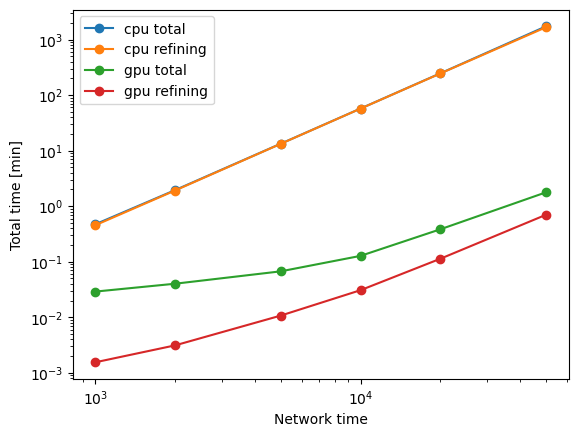

In [38]:
for name, group in df.groupby("backend"):
    plt.plot(group['size'], group['total_time_ms'] / 1000 / 60, 'o-', label=f'{name} total')
    plt.plot(group['size'], group['refining_positions_ms'] / 1000 / 60, 'o-', label=f'{name} refining')
plt.legend()
plt.xlabel('Network time')
plt.ylabel('Total time [min]')
plt.xscale("log")
plt.yscale("log")

# plt.savefig("cpu_vs_gpu_time.png")

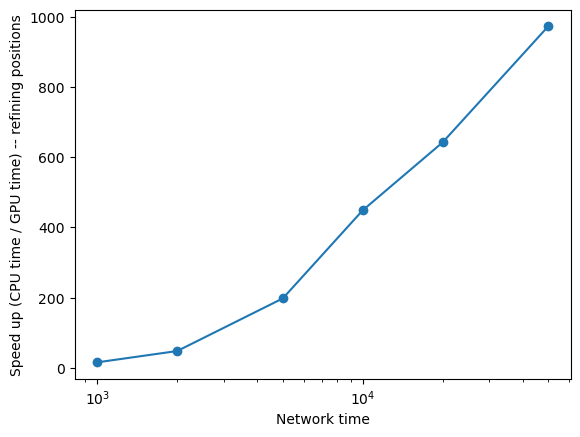

In [39]:
speed_up = []
sizes = []

for name, group in df.groupby("size"):
    sizes.append(name)
    cpu_time = group[group['backend'] == 'cpu']['total_time_ms'].values[0]
    gpu_time = group[group['backend'] == 'gpu']['total_time_ms'].values[0]
    
    speed_up.append(cpu_time / gpu_time)

plt.plot(sizes, speed_up, 'o-')
plt.xlabel('Network time')
plt.ylabel('Speed up (CPU time / GPU time) -- refining positions')
plt.xscale("log")
# plt.savefig("cpu_vs_gpu_speedup.png")


In [40]:
def fit_loglog(sub):
    x = np.log10(sub["size"].to_numpy(dtype=float))
    y = np.log10(sub["total_time_ms"].to_numpy(dtype=float))
    alpha, beta = np.polyfit(x, y, 1)
    yhat = alpha*x + beta
    r2 = 1 - ((y - yhat)**2).sum() / ((y - y.mean())**2).sum() if len(y) > 1 else np.nan
    c = 10**beta
    return alpha, beta, c, r2

for backend, sub in df.groupby("backend"):
    alpha, beta, c, r2 = fit_loglog(sub)
    print(backend, alpha, beta, c, r2)

cpu 2.1000063167267906 -1.8588760784520029 0.013839612220061756 0.9999703805515241
gpu 1.0319829107472374 -0.03821498145457875 0.915767061219577 0.9320021247496013


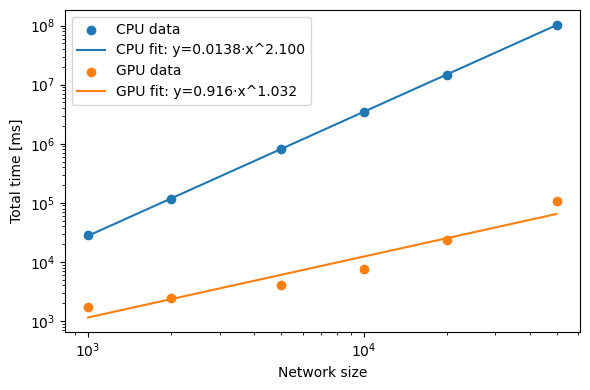

In [41]:
fits = {b: fit_loglog(sub) for b, sub in df.groupby("backend")}

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

for backend, sub in df.groupby("backend"):
    ax.scatter(sub["size"], sub["total_time_ms"], label=f"{backend.upper()} data")

    alpha, beta, c, r2 = fits[backend]
    # Use range of x for that backend
    x_min, x_max = sub["size"].min(), sub["size"].max()
    xs = np.logspace(np.log10(x_min), np.log10(x_max), 200)
    ys = c * xs**alpha
    ax.plot(xs, ys, label=f"{backend.upper()} fit: y={c:.3g}·x^{alpha:.3f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Network size")
ax.set_ylabel("Total time [ms]")
ax.legend()
plt.tight_layout()
plt.show()


In [42]:
def fit_loglog(sub):
    x = np.log10(sub["size"].to_numpy(dtype=float))
    y = np.log10(sub["total_time_ms"].to_numpy(dtype=float))
    alpha, beta = np.polyfit(x, y, 1)
    c = 10**beta
    return alpha, c, beta
    
fits = {}
for backend, sub in df.groupby("backend"):
    alpha, c, beta = fit_loglog(sub)
    fits[backend] = {"alpha": alpha, "c": c, "beta": beta}

sizes = np.array([20000, 100_000, 500_000, 1_000_000, 1_500_000, 2_000_000], dtype=float)

rows = []
for n in sizes:
    row = {"size": int(n)}
    for backend in ["cpu", "gpu"]:
        alpha = fits[backend]["alpha"]
        c = fits[backend]["c"]
        y_ms = c * (n ** alpha)
        row[f"{backend}_pred_ms"] = y_ms
        row[f"{backend}_pred_s"] = y_ms / 1000.0
        row[f"{backend}_pred_min"] = y_ms / (1000.0 * 60.0)
        row[f"{backend}_pred_h"] = y_ms / (1000.0 * 3600.0)
    rows.append(row)

pred = pd.DataFrame(rows)

pred

,size,cpu_pred_ms,cpu_pred_s,cpu_pred_min,cpu_pred_h,gpu_pred_ms,gpu_pred_s,gpu_pred_min,gpu_pred_h
0,20000,1.490439e+07,1.490439e+04,2.484064e+02,4.140107,2.514053e+04,25.140533,0.419009,0.006983
1,100000,4.376788e+08,4.376788e+05,7.294647e+03,121.577443,1.323426e+05,132.342572,2.205710,0.036762
2,500000,1.285278e+10,1.285278e+07,2.142129e+05,3570.215480,6.966661e+05,696.666090,11.611101,0.193518
3,1000000,5.510130e+10,5.510130e+07,9.183550e+05,15305.915844,1.424566e+06,1424.565699,23.742762,0.395713
4,1500000,1.291084e+11,1.291084e+08,2.151807e+06,35863.450982,2.164740e+06,2164.739556,36.078993,0.601317
5,2000000,2.362255e+11,2.362255e+08,3.937091e+06,65618.184990,2.912999e+06,2912.998723,48.549979,0.809166


In [43]:
coords_cpu = pd.read_csv("../benchmark_runs/60349385/artifacts/d1_n50000_seed1062345/embed_cpu_rep00.coords.csv")
coords_gpu = pd.read_csv("../benchmark_runs/60349385/artifacts/d1_n50000_seed1062345/embed_gpu_rep00.coords.csv")
coords_original = pd.read_csv("../benchmark_runs/60349385/artifacts/d1_n50000_seed1062345/synthetic_sd.truth.csv")

# coords_cpu = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n1000_seed1013345/embed_cpu_rep00.coords.csv")
# coords_gpu = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n1000_seed1013345/embed_gpu_rep00.coords.csv")
# coords_original = pd.read_csv("../benchmark_runs/60054709/artifacts/d1_n1000_seed1013345/synthetic_sd.truth.csv")

In [44]:
coords_cpu.columns = ['node_id', 'r_cpu', 'kappa_cpu', 'theta_cpu']
coords_gpu.columns = ['node_id', 'r_gpu', 'kappa_gpu', 'theta_gpu']

coords = coords_cpu.merge(coords_original, on='node_id')
coords = coords.merge(coords_gpu, on='node_id')
coords.head()

,node_id,r_cpu,kappa_cpu,theta_cpu,r,kappa,theta_0,r_gpu,kappa_gpu,theta_gpu
0,v0,48.8907,3.68318,5.83234,25.1293,4.21498,0.913700,48.8907,3.68318,5.83234
1,v1,47.8265,6.27067,4.58908,24.9404,4.63244,2.196290,47.8265,6.27067,4.58908
2,v10,48.1444,5.34895,1.82622,24.0709,7.15523,4.930180,48.1444,5.34895,1.82622
3,v100,47.4386,7.61281,6.21309,23.3395,10.31460,0.527381,47.4386,7.61281,6.21309
4,v1000,48.2932,4.96554,1.48811,25.0306,4.42821,5.269930,48.2932,4.96554,1.48811


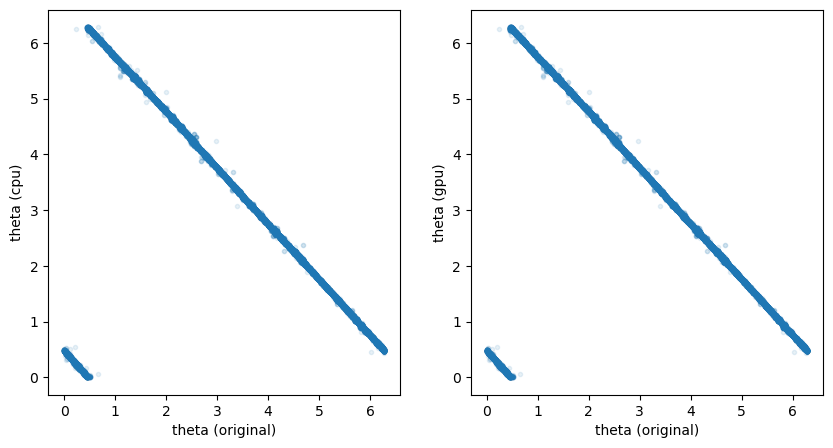

In [46]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.scatter(coords['theta_0'], coords['theta_cpu'], marker='.', alpha=0.1)
plt.xlabel('theta (original)')
plt.ylabel('theta (cpu)')

plt.subplot(1, 2, 2)
plt.scatter(coords['theta_0'], coords['theta_gpu'], marker='.', alpha=0.1)
plt.xlabel('theta (original)')
plt.ylabel('theta (gpu)')

# plt.savefig("cpu_vs_gpu_theta.png")

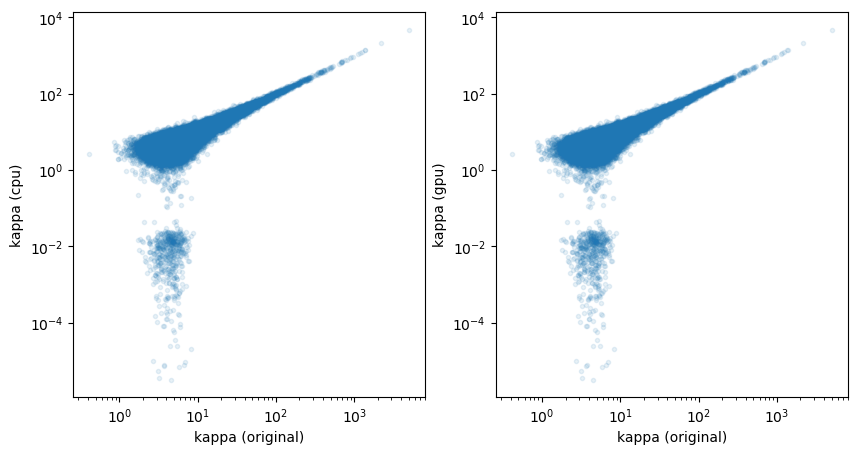

In [47]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.scatter(coords['kappa'], coords['kappa_cpu'], marker='.', alpha=0.1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'kappa (original)')
plt.ylabel(r'kappa (cpu)')

plt.subplot(1, 2, 2)
plt.scatter(coords['kappa'], coords['kappa_gpu'], marker='.', alpha=0.1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'kappa (original)')
plt.ylabel(r'kappa (gpu)')

# plt.savefig("cpu_vs_gpu_kappa.png")

In [48]:
df_gpu = pd.read_csv("../benchmark_runs/60349464/cpu_gpu_benchmark.csv")
df_gpu

,size,rep,dimension,graph_seed,embed_seed,beta,backend,backend_reported,mode,build_dir,...,nb_edges_reported,graph_generation_wall_ms,wall_time_ms,total_time_ms,initialization_ms,parameter_inference_ms,initial_positions_ms,refining_positions_ms,adjusting_kappas_ms,io_ms
0,5000,0,1,1017345,1017345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,24332,1.042938e+03,4.069743e+03,3.903322e+03,411.569618,2104.108923,5.638446e+02,7.641496e+02,3.449729e+01,25.133602
1,10000,0,1,1022345,1022345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,49108,1.564507e+03,7.165326e+03,6.996301e+03,687.061687,2735.673861,1.615521e+03,1.835037e+03,8.106572e+01,41.921945
2,20000,0,1,1032345,1032345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,101628,3.431717e+03,2.241385e+04,2.221617e+04,1478.952847,4098.533826,8.956190e+03,6.812172e+03,7.828672e+02,87.425551
3,50000,0,1,1062345,1062345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,246154,1.571701e+04,1.059957e+05,1.057067e+05,4036.036016,6023.432847,3.439455e+04,4.214055e+04,1.894575e+04,166.333876
4,100000,0,1,1112345,1112345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,498463,5.743355e+04,4.324160e+05,4.319497e+05,13479.328199,8824.989799,1.912099e+05,1.629325e+05,5.514417e+04,358.699134
5,200000,0,1,1212345,1212345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,1005455,2.249104e+05,1.776296e+06,1.775490e+06,31661.852106,13380.851061,8.237310e+05,7.021487e+05,2.039401e+05,627.507253
6,500000,0,1,1512345,1512345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,2512484,1.368909e+06,1.161940e+07,1.161740e+07,149256.976075,21258.045765,5.897750e+06,4.340573e+06,1.207019e+06,1544.649320
7,1000000,0,1,2012345,2012345,2.0,gpu,cuda,optimized,/n/holylabs/mweber_lab/Everyone/rjankowski/rep...,...,5051231,9.942005e+06,5.813861e+07,5.813460e+07,660050.353975,30927.858184,3.382146e+07,1.888223e+07,4.736690e+06,3243.683380


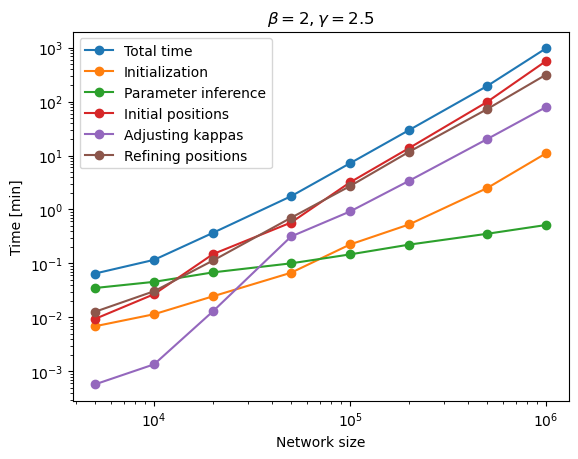

In [49]:
plt.plot(df_gpu['size'], df_gpu['total_time_ms']/1000/60, 'o-', label='Total time')
plt.plot(df_gpu['size'], df_gpu['initialization_ms']/1000/60, 'o-', label='Initialization')
plt.plot(df_gpu['size'], df_gpu['parameter_inference_ms']/1000/60, 'o-', label='Parameter inference')
plt.plot(df_gpu['size'], df_gpu['initial_positions_ms']/1000/60, 'o-', label='Initial positions')
plt.plot(df_gpu['size'], df_gpu['adjusting_kappas_ms']/1000/60, 'o-', label='Adjusting kappas')
plt.plot(df_gpu['size'], df_gpu['refining_positions_ms']/1000/60, 'o-', label='Refining positions')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Network size')
plt.ylabel('Time [min]')
plt.title(r'$\beta=2,\gamma=2.5$')

# plt.savefig("gpu_time.png")

In [21]:
def fit_loglog(sub):
    x = np.log10(sub["size"].to_numpy(dtype=float))
    y = np.log10(sub["total_time_ms"].to_numpy(dtype=float))
    alpha, beta = np.polyfit(x, y, 1)
    c = 10**beta
    return alpha, c, beta
    
fits = {}
for backend, sub in df_gpu.groupby("backend"):
    alpha, c, beta = fit_loglog(sub)
    fits[backend] = {"alpha": alpha, "c": c, "beta": beta}

sizes = np.array([20000, 100_000, 500_000, 1_000_000, 1_500_000, 2_000_000], dtype=float)

rows = []
for n in sizes:
    row = {"size": int(n)}
    for backend in ["gpu"]:
        alpha = fits[backend]["alpha"]
        c = fits[backend]["c"]
        y_ms = c * (n ** alpha)
        row[f"{backend}_pred_ms"] = y_ms
        row[f"{backend}_pred_s"] = y_ms / 1000.0
        row[f"{backend}_pred_min"] = y_ms / (1000.0 * 60.0)
        row[f"{backend}_pred_h"] = y_ms / (1000.0 * 3600.0)
    rows.append(row)

pred = pd.DataFrame(rows)

pred

,size,gpu_pred_ms,gpu_pred_s,gpu_pred_min,gpu_pred_h
0,20000,2.797008e+04,27.970079,0.466168,0.007769
1,100000,5.513308e+05,551.330783,9.188846,0.153147
2,500000,1.086753e+07,10867.528407,181.125473,3.018758
3,1000000,3.924061e+07,39240.606364,654.010106,10.900168
4,1500000,8.315985e+07,83159.846952,1385.997449,23.099957
5,2000000,1.416905e+08,141690.468174,2361.507803,39.358463


In [32]:
# from ogb.linkproppred import LinkPropPredDataset

# def save_ogbl_ppa_edgelist(
#     root="data/ogb",
#     out_path="ogbl-ppa.edgelist",
#     make_undirected_unique=True,   # set False to write edges exactly as stored
# ):
#     dataset = LinkPropPredDataset(name="ogbl-ppa", root=root)
#     graph = dataset[0]
#     edge_index = graph["edge_index"]  # shape (2, E), 0-based node ids

#     src = edge_index[0].astype(np.int64)
#     dst = edge_index[1].astype(np.int64)

#     if make_undirected_unique:
#         # canonicalize each edge as (min, max) then unique
#         u = np.minimum(src, dst)
#         v = np.maximum(src, dst)
#         edges = np.stack([u, v], axis=1)
#         edges = np.unique(edges, axis=0)
#     else:
#         edges = np.stack([src, dst], axis=1)

#     np.savetxt(out_path, edges, fmt="%d %d")
#     return edges.shape[0], out_path

# m, path = save_ogbl_ppa_edgelist(
#     root="data/ogb",
#     out_path="ogbl-ppa.edgelist",
#     make_undirected_unique=True
# )
# print(f"Saved {m} edges to {path}")

Text(0.5, 1.0, '$\\beta=2,\\gamma=2.5$')

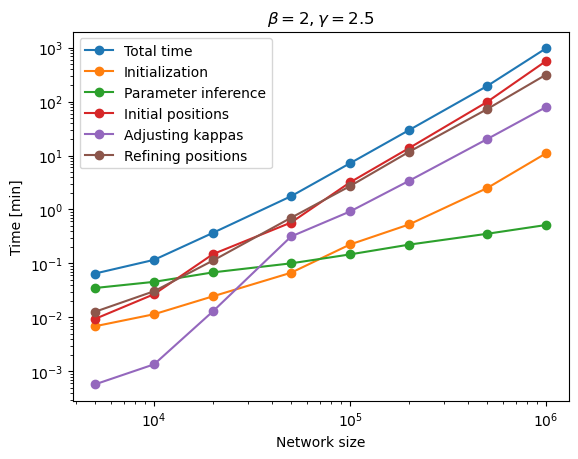

In [52]:
plt.plot(df_gpu['size'], df_gpu['total_time_ms']/1000/60, 'o-', label='Total time')
plt.plot(df_gpu['size'], df_gpu['initialization_ms']/1000/60, 'o-', label='Initialization')
plt.plot(df_gpu['size'], df_gpu['parameter_inference_ms']/1000/60, 'o-', label='Parameter inference')
plt.plot(df_gpu['size'], df_gpu['initial_positions_ms']/1000/60, 'o-', label='Initial positions')
plt.plot(df_gpu['size'], df_gpu['adjusting_kappas_ms']/1000/60, 'o-', label='Adjusting kappas')
plt.plot(df_gpu['size'], df_gpu['refining_positions_ms']/1000/60, 'o-', label='Refining positions')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Network size')
plt.ylabel('Time [min]')
plt.title(r'$\beta=2,\gamma=2.5$')

# plt.savefig("gpu_time.png")

In [56]:
df_gpu['total_time_h'] = df_gpu['total_time_ms'] / 1000 / 60 / 60

print(df_gpu[['size', 'total_time_h']].to_latex())

\begin{tabular}{lrr}
\toprule
 & size & total_time_h \\
\midrule
0 & 5000 & 0.001084 \\
1 & 10000 & 0.001943 \\
2 & 20000 & 0.006171 \\
3 & 50000 & 0.029363 \\
4 & 100000 & 0.119986 \\
5 & 200000 & 0.493192 \\
6 & 500000 & 3.227056 \\
7 & 1000000 & 16.148501 \\
\bottomrule
\end{tabular}

